# 📊 Exploratory Data Analysis (EDA)

## 🎯 Objective

In this notebook, I prepare the expanded property dataset for:

- Financial modeling (ROI, yield, cash flow)
- Feature engineering
- Machine learning

This step is critical because:

👉 Poor data = wrong investment decisions  
👉 Clean + structured data = reliable financial insights


## 1) Imports and setup

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.options.display.float_format = '{:,.2f}'.format

sns.set_style("whitegrid")

## 2) Upload Dataset

In [12]:
df = pd.read_csv("data\processed\expanded_sales_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (10000, 26)


,source_site,listing_id,listing_url,title,purchase_price,suburb,city,province,property_type,bedrooms,bathrooms,parking_spaces,garage,floor_area_sqm,land_area_sqm,levies,rates_taxes,description,listing_date,scraped_timestamp,pp_transaction_slug,pp_province_slug,pp_metro_slug,pp_city_slug,pp_suburb_slug,purchase_price_Rands
0,privateproperty,T5332132,https://www.privateproperty.co.za/for-sale/gau...,2 Bedroom Apartment in Broadacres,"8,900,000.00",Broadacres,Sandton,Gauteng,Apartment,2.00,2.00,1.00,NaN,85.00,5.00,"2,693.00",840.00,"2 Bedroom Apartment in Broadacres, Airbnb Oppo...",11 Dec 2025,2026-03-27T16:32:22.940146+00:00,for-sale,gauteng,johannesburg-metro,sandton,broadacres,"890,000.00"
1,privateproperty,T5405954,https://www.privateproperty.co.za/for-sale/gau...,2 Bedroom Apartment in Sundowner,"8,850,000.00",Sundowner,North Riding To Lanseria,Gauteng,Apartment,2.00,1.00,1.00,NaN,105.00,NaN,"1,741.50",446.00,"2 Bedroom Apartment in Sundowner, High-demand,...",27 Feb 2026,2026-03-27T16:32:19.698613+00:00,for-sale,gauteng,johannesburg-metro,north-riding-to-lanseria,sundowner,"885,000.00"
2,privateproperty,T5374159,https://www.privateproperty.co.za/for-sale/gau...,2 Bedroom Apartment in Jackal Creek Golf Estate,"8,800,000.00",Jackal Creek Northriding,North Riding To Lanseria,Gauteng,Apartment,2.00,2.00,3.00,NaN,71.00,NaN,"2,696.00",540.00,2 Bedroom Apartment in Jackal Creek Golf Estat...,3 Feb 2026,2026-03-27T16:32:15.389505+00:00,for-sale,gauteng,johannesburg-metro,north-riding-to-lanseria,jackal-creek-northriding,"880,000.00"
3,privateproperty,T5078482,https://www.privateproperty.co.za/for-sale/gau...,2 Bedroom Apartment in Braamfontein,"8,600,000.00",Braamfontein,Johannesburg Central,Gauteng,Apartment,2.00,1.00,NaN,NaN,90.00,NaN,"2,517.00",568.00,"2 Bedroom Apartment in Braamfontein, A Rare ge...",15 May 2025,2026-03-27T16:32:11.817664+00:00,for-sale,gauteng,johannesburg-metro,johannesburg-central,braamfontein,"860,000.00"
4,privateproperty,T4938016,https://www.privateproperty.co.za/for-sale/gau...,2 Bedroom Apartment in Lonehill,"8,500,000.00",Lonehill,Sandton,Gauteng,Apartment,2.00,1.00,1.00,NaN,67.00,67.00,"2,103.00",830.00,"2 Bedroom Apartment in Lonehill, FOR SALE: 2-B...",29 Jan 2025,2026-03-27T16:32:08.500709+00:00,for-sale,gauteng,johannesburg-metro,sandton,lonehill,"850,000.00"


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   source_site           10000 non-null  object 
 1   listing_id            10000 non-null  object 
 2   listing_url           10000 non-null  object 
 3   title                 10000 non-null  object 
 4   purchase_price        10000 non-null  float64
 5   suburb                10000 non-null  object 
 6   city                  10000 non-null  object 
 7   province              10000 non-null  object 
 8   property_type         9967 non-null   object 
 9   bedrooms              10000 non-null  float64
 10  bathrooms             10000 non-null  float64
 11  parking_spaces        9882 non-null   float64
 12  garage                9432 non-null   float64
 13  floor_area_sqm        9790 non-null   float64
 14  land_area_sqm         9582 non-null   float64
 15  levies              

In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
source_site,10000,1,privateproperty,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listing_id,10000,10000,T5332132,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listing_url,10000,10000,https://www.privateproperty.co.za/for-sale/gau...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,10000,1720,2 Bedroom House in Protea Glen,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_price,"10,000.00",NaN,NaN,NaN,"26,268,477.23","35,653,977.01","500,000.00","7,540,000.00","12,955,000.00","29,122,500.00","300,000,000.00"
suburb,10000,201,Bryanston,458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,10000,11,Sandton,2930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province,10000,1,Gauteng,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_type,9967,2,House,6155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,"10,000.00",NaN,NaN,NaN,2.66,1.59,0.00,2.00,2.75,4.00,16.00


### 🧠 Observations

- Which columns are numeric?
- Which should be numeric but are objects?
- Any obvious missing data?

In [15]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.columns.tolist()

['source_site',
 'listing_id',
 'listing_url',
 'title',
 'purchase_price',
 'suburb',
 'city',
 'province',
 'property_type',
 'bedrooms',
 'bathrooms',
 'parking_spaces',
 'garage',
 'floor_area_sqm',
 'land_area_sqm',
 'levies',
 'rates_taxes',
 'description',
 'listing_date',
 'scraped_timestamp',
 'pp_transaction_slug',
 'pp_province_slug',
 'pp_metro_slug',
 'pp_city_slug',
 'pp_suburb_slug',
 'purchase_price_rands']

In [24]:
# Ensure correct column exists
if "purchase_price_rands" in df.columns:
    df["purchase_price"] = df["purchase_price_rands"]

# Remove invalid values
df = df[df["purchase_price"] > 0]

df["purchase_price"].describe()

count       10,000.00
mean     2,626,847.72
std      3,565,397.70
min         50,000.00
25%        754,000.00
50%      1,295,500.00
75%      2,912,250.00
max     30,000,000.00
Name: purchase_price, dtype: float64

### Decision

- `purchase_price_rands` becomes the canonical price
- All zero/negative values removed

## 3) Check for missing values

In [17]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": (missing / len(df)) * 100
})

missing_df

,missing_count,missing_pct
garage,568,5.68
land_area_sqm,418,4.18
floor_area_sqm,210,2.10
parking_spaces,118,1.18
property_type,33,0.33
levies,0,0.00
pp_suburb_slug,0,0.00
pp_city_slug,0,0.00
pp_metro_slug,0,0.00
pp_province_slug,0,0.00


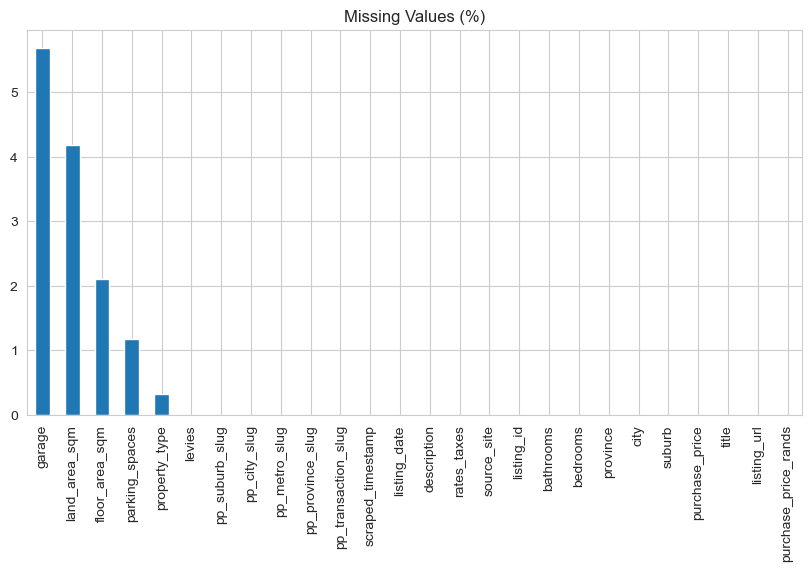

In [18]:
# Visual
plt.figure(figsize=(10,5))
missing_df["missing_pct"].plot(kind="bar")
plt.title("Missing Values (%)")
plt.show()

## 4) Exploratory DAta Analysis (EDA)

In [19]:
numeric_cols = [
    "bedrooms",
    "bathrooms",
    "parking",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

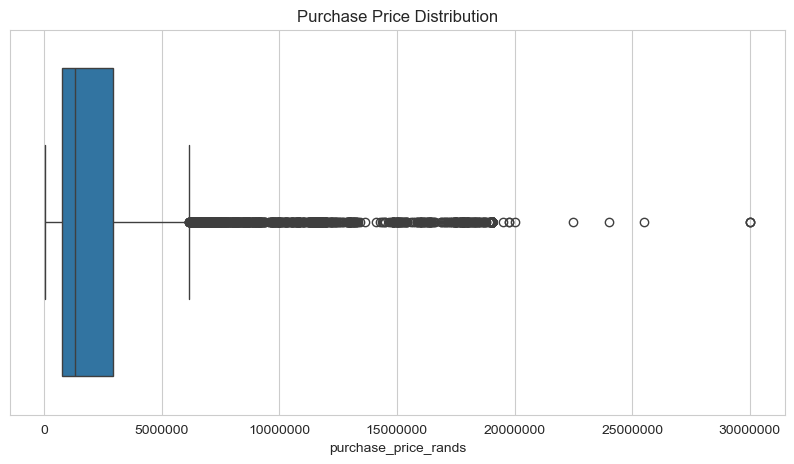

In [26]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["purchase_price_rands"])

plt.ticklabel_format(style='plain', axis='x') 
plt.title("Purchase Price Distribution")

plt.show()

In [28]:
# Remove extreme outliers (optional)

q1 = df["purchase_price"].quantile(0.25)
q3 = df["purchase_price"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df = df[(df["purchase_price"] >= lower) & (df["purchase_price"] <= upper)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 754000.0
Q3: 2912250.0
IQR: 2158250.0


In [30]:
# Ensure correct column exists
if "purchase_price_rands" in df.columns:
    df["purchase_price"] = df["purchase_price_rands"]

# Remove invalid values
df = df[df["purchase_price"] > 0]

df["purchase_price"].describe()

count       9,009.00
mean    1,637,326.15
std     1,318,018.31
min        50,000.00
25%       720,000.00
50%     1,148,000.00
75%     2,214,000.00
max     6,147,000.00
Name: purchase_price, dtype: float64

### 🧠 Why this matters

Outliers distort:

- ROI calculations
- Model training

In [32]:
if "suburb" in df.columns:
    df["suburb"] = df["suburb"].str.strip().str.title()

df["suburb"].value_counts().head(10)

suburb
Protea Glen                 411
Ferndale                    373
Bryanston                   318
Lonehill                    249
Fourways                    240
Paulshof                    219
Noordwyk                    213
Morningside                 212
North Riding                181
Jackal Creek Northriding    180
Name: count, dtype: int64

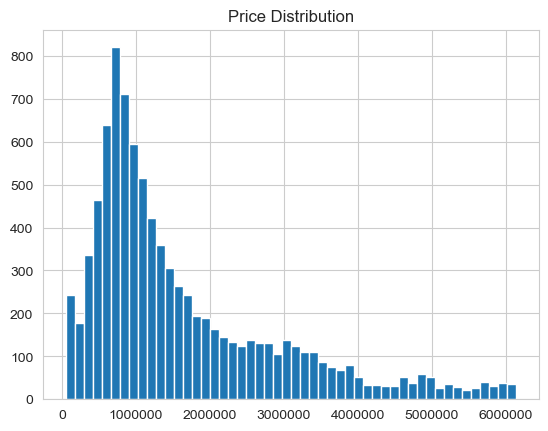

In [34]:
df["purchase_price"].hist(bins=50)
plt.ticklabel_format(style='plain', axis='x')
plt.title("Price Distribution")
plt.show()

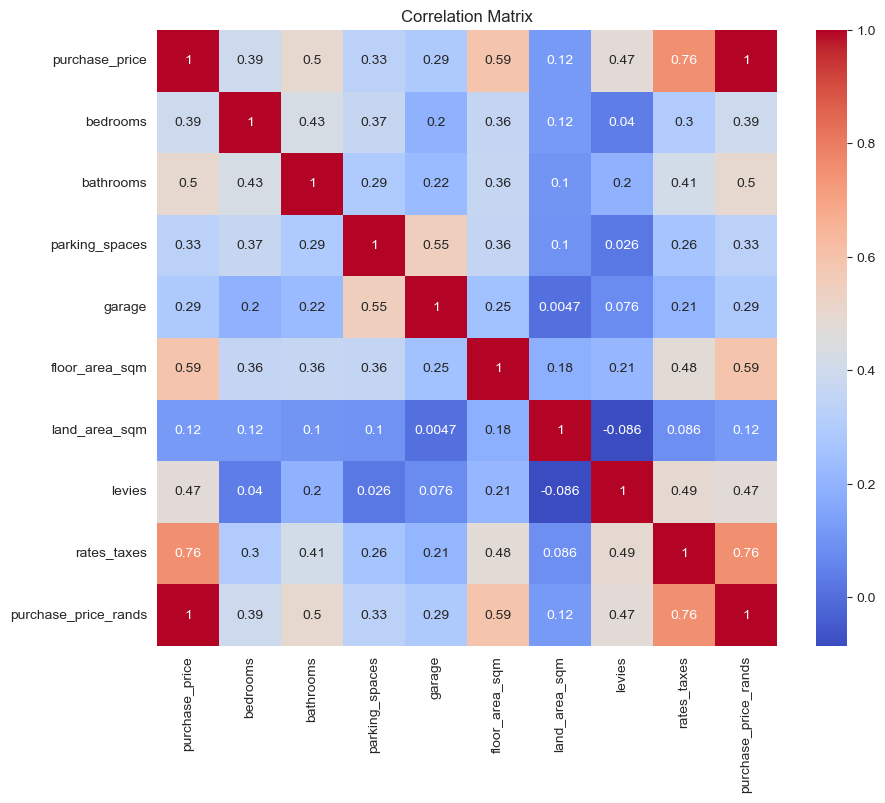

In [35]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### 🧠 Insight Goal

Identify variables influencing:

- Price
- Rent (later merge)

In [37]:
assert (df["purchase_price"] > 0).all(), "Invalid price detected"

if "bedrooms" in df.columns:
    assert (df["bedrooms"] >= 0).all()

In [56]:
df.to_csv("data/processed/eda_ready_sales_data.csv", index=False)

print("✅ Data ready for Financial Engine")

✅ Data ready for Financial Engine


##  4.1 Price per Suburb Analysis

In this section, I analyse how purchase prices vary across suburbs.

This helps me answer questions like:

- Which suburbs are the most expensive?
- Which suburbs appear more affordable?
- Which suburbs have enough listing volume to trust the averages?

This is important for downstream financial logic because suburb is one of the strongest drivers of:

- purchase price
- rental potential
- expected yield
- investor affordability

In [38]:
# Suburb-level pricing summary
suburb_price_summary = (
    df.groupby("suburb", dropna=False)
      .agg(
          listings=("suburb", "count"),
          avg_price=("purchase_price", "mean"),
          median_price=("purchase_price", "median"),
          min_price=("purchase_price", "min"),
          max_price=("purchase_price", "max")
      )
      .sort_values("avg_price", ascending=False)
)

suburb_price_summary.head(20)

,listings,avg_price,median_price,min_price,max_price
suburb,,,,,
Woodmead,2,"6,061,000.00","6,061,000.00","6,000,000.00","6,122,000.00"
Cedar Creek,8,"5,349,125.00","5,839,500.00","1,624,000.00","6,109,000.00"
Eye Of Africa,14,"4,709,714.29","5,756,000.00","501,000.00","6,046,000.00"
Parktown,11,"4,642,454.55","4,900,000.00","1,265,000.00","5,617,000.00"
Khyber Rock,8,"4,603,625.00","4,904,000.00","1,099,000.00","5,958,000.00"
Dunkeld,7,"4,365,857.14","4,300,000.00","4,153,000.00","4,616,000.00"
Greenside,21,"4,316,333.33","4,151,000.00","980,000.00","5,633,000.00"
Aspen Hills,8,"4,268,500.00","4,590,000.00","1,724,000.00","5,017,000.00"
Bedfordview,29,"4,181,034.48","4,925,000.00","705,000.00","6,112,000.00"


## 4.2 Price per Bedroom Analysis

In this section, I compare purchase price by bedroom count.

This helps me understand:

- whether larger homes are consistently more expensive
- whether some bedroom categories are overpriced
- whether bedroom count is a strong financial driver

This also helps with downstream feature engineering because bedroom count is a core structural feature.

In [43]:
# Summary by bedroom count
bedroom_price_summary = (
    bedroom_df.groupby("bedrooms")
              .agg(
                  listings=("bedrooms", "count"),
                  avg_price=("purchase_price", "mean"),
                  median_price=("purchase_price", "median")
              )
              .sort_index()
)

bedroom_price_summary

,listings,avg_price,median_price
bedrooms,,,
0.00,670,"1,060,491.19","821,000.00"
0.50,7,"716,732.14","550,000.00"
1.00,1594,"1,155,652.16","879,500.00"
1.50,2,"325,000.00","325,000.00"
2.00,2571,"1,335,445.53","975,000.00"
2.50,3,"3,576,433.33","3,999,000.00"
3.00,2265,"1,766,130.65","1,391,000.00"
3.50,3,"3,711,666.67","3,785,000.00"
4.00,1190,"2,205,359.50","1,933,000.00"


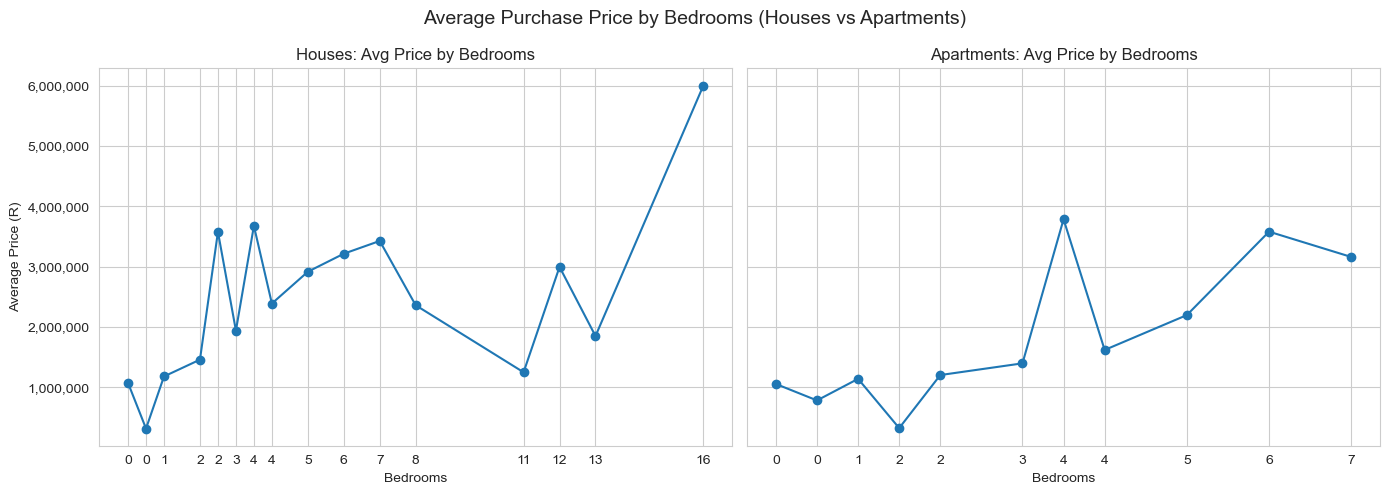

In [49]:
# -----------------------------
# 1. Filter data
# -----------------------------
houses = df[df["property_type"] == "House"]
apartments = df[df["property_type"] == "Apartment"]

# -----------------------------
# 2. Group by bedrooms
# -----------------------------
house_summary = houses.groupby("bedrooms")["purchase_price_rands"].mean()
apartment_summary = apartments.groupby("bedrooms")["purchase_price_rands"].mean()

# -----------------------------
# 3. Plot side-by-side
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Houses ---
axes[0].plot(house_summary.index, house_summary.values, marker="o")
axes[0].set_title("Houses: Avg Price by Bedrooms")
axes[0].set_xlabel("Bedrooms")
axes[0].set_ylabel("Average Price (R)")
axes[0].set_xticks(house_summary.index)
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# --- Apartments ---
axes[1].plot(apartment_summary.index, apartment_summary.values, marker="o")
axes[1].set_title("Apartments: Avg Price by Bedrooms")
axes[1].set_xlabel("Bedrooms")
axes[1].set_xticks(apartment_summary.index)
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.suptitle("Average Purchase Price by Bedrooms (Houses vs Apartments)", fontsize=14)

plt.tight_layout()
plt.show()

## 4.3 Heatmaps per Location

In this section, I use pivot-style heatmaps to detect spatial pricing patterns.

If exact latitude and longitude are not available, I can still build useful heatmaps using:

- suburb × property type
- suburb × bedrooms
- city × suburb
- suburb × average price

These heatmaps help identify clusters of high-value and low-value areas.

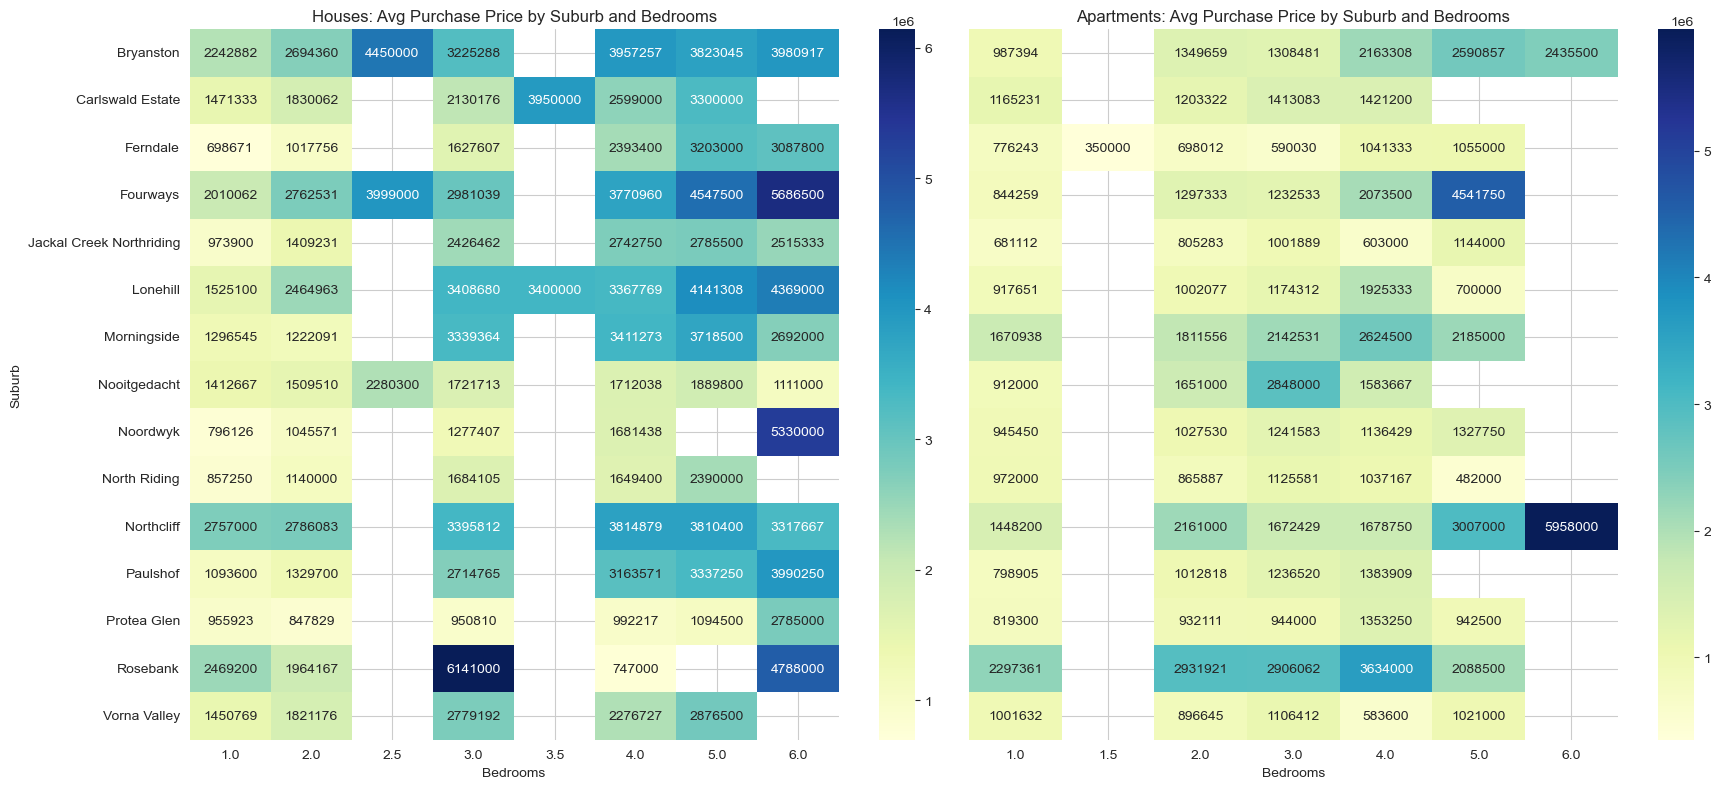

In [50]:
# Run only if required columns exist
required_cols = ["suburb", "property_type", "bedrooms", "purchase_price"]
if all(col in df.columns for col in required_cols):
    
    # Clean property_type
    df["property_type"] = (
        df["property_type"]
        .astype(str)
        .str.strip()
        .str.title()
    )

    # Keep only Houses and Apartments
    df_plot = df[df["property_type"].isin(["House", "Apartment"])].copy()

    # Top 15 suburbs by frequency
    top_suburbs = df_plot["suburb"].value_counts().head(15).index
    df_plot = df_plot[df_plot["suburb"].isin(top_suburbs)]

    # Optional: keep bedroom counts reasonable for cleaner charts
    df_plot = df_plot[df_plot["bedrooms"].between(1, 6)]

    # House heatmap: suburb vs bedrooms
    house_data = (
        df_plot[df_plot["property_type"] == "House"]
        .groupby(["suburb", "bedrooms"])["purchase_price"]
        .mean()
        .reset_index()
        .pivot(index="suburb", columns="bedrooms", values="purchase_price")
    )

    # Apartment heatmap: suburb vs bedrooms
    apartment_data = (
        df_plot[df_plot["property_type"] == "Apartment"]
        .groupby(["suburb", "bedrooms"])["purchase_price"]
        .mean()
        .reset_index()
        .pivot(index="suburb", columns="bedrooms", values="purchase_price")
    )

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

    sns.heatmap(house_data, annot=True, fmt=".0f", ax=axes[0], cmap="YlGnBu")
    axes[0].set_title("Houses: Avg Purchase Price by Suburb and Bedrooms")
    axes[0].set_xlabel("Bedrooms")
    axes[0].set_ylabel("Suburb")

    sns.heatmap(apartment_data, annot=True, fmt=".0f", ax=axes[1], cmap="YlGnBu")
    axes[1].set_title("Apartments: Avg Purchase Price by Suburb and Bedrooms")
    axes[1].set_xlabel("Bedrooms")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

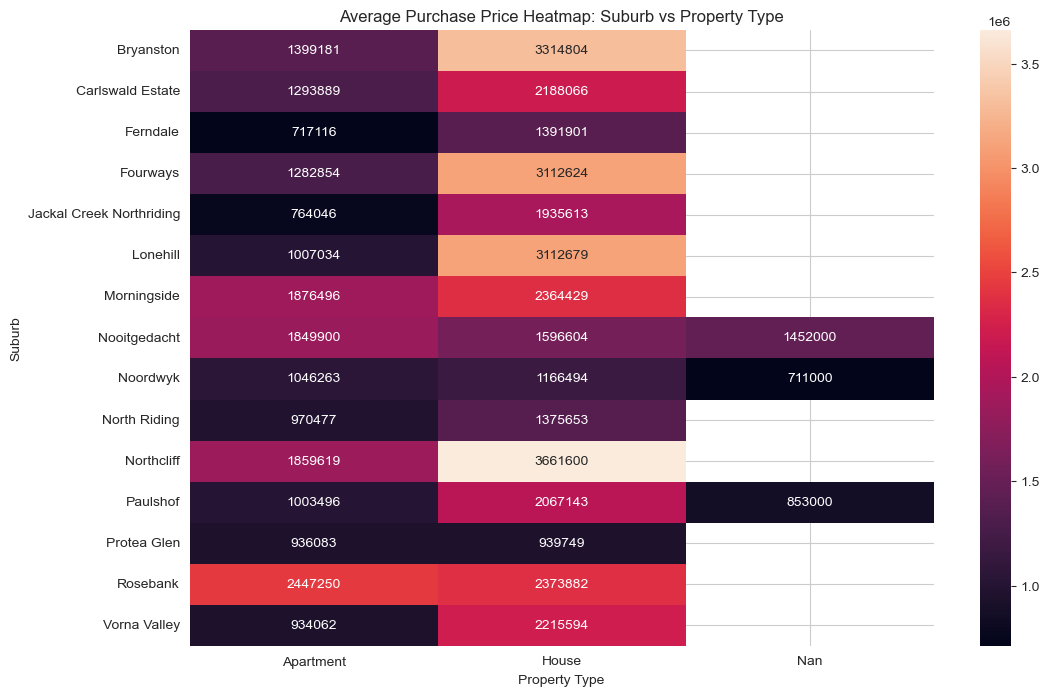

In [51]:
# Run only if property_type exists
if "property_type" in df.columns:
    df["property_type"] = (
        df["property_type"]
        .astype(str)
        .str.strip()
        .str.title()
    )

    heatmap_property = (
        df.groupby(["suburb", "property_type"])["purchase_price"]
          .mean()
          .reset_index()
          .pivot(index="suburb", columns="property_type", values="purchase_price")
    )

    top_suburbs = df["suburb"].value_counts().head(15).index
    heatmap_property_top = heatmap_property.loc[
        heatmap_property.index.intersection(top_suburbs)
    ]

    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_property_top, annot=True, fmt=".0f")
    plt.title("Average Purchase Price Heatmap: Suburb vs Property Type")
    plt.xlabel("Property Type")
    plt.ylabel("Suburb")
    plt.show()

## 4.4 Distribution by Property Type

In this section, I analyse how listings are distributed across property types.

This helps me understand:

- which property types dominate the dataset
- whether the dataset is imbalanced
- whether certain property types have much higher or lower prices

This is important because property type can strongly affect:
- price
- rent
- maintenance
- financing assumptions
- investor suitability

In [53]:
if "property_type" in df.columns:
    property_type_summary = (
        df.groupby("property_type")
          .agg(
              listings=("property_type", "count"),
              avg_price=("purchase_price", "mean"),
              median_price=("purchase_price", "median")
          )
          .sort_values("listings", ascending=False)
    )

    property_type_summary

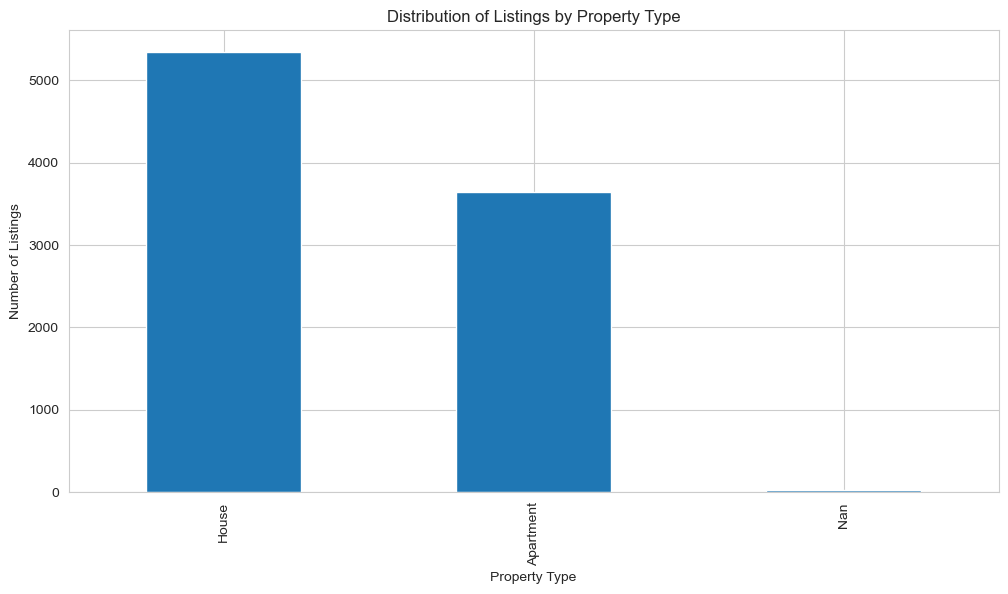

In [54]:
if "property_type" in df.columns:
    plt.figure(figsize=(12, 6))
    df["property_type"].value_counts().plot(kind="bar")
    plt.title("Distribution of Listings by Property Type")
    plt.xlabel("Property Type")
    plt.ylabel("Number of Listings")
    plt.show()

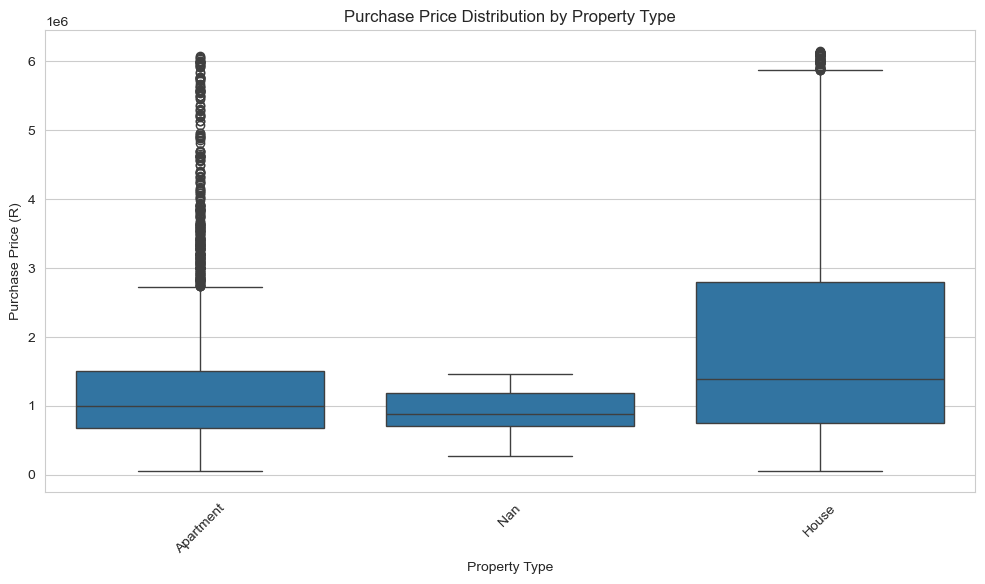

In [55]:
if "property_type" in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="property_type", y="purchase_price")
    plt.title("Purchase Price Distribution by Property Type")
    plt.xlabel("Property Type")
    plt.ylabel("Purchase Price (R)")
    plt.xticks(rotation=45)
    plt.show()